# Моделирование распространения сигнала в аудитории 8507
Анализ многолучевого распространения, импульсной и частотной характеристик канала с помощью Sionna RT.

In [26]:
# Установка Sionna RT, если отсутствует
try:
    import sionna.rt
except ImportError:
    import os
    os.system("pip install sionna-rt")
    import sionna.rt

## 1. Импорты

In [27]:
import os
import json
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import drjit as dr
import mitsuba as mi

import sionna.rt
from sionna.rt import (load_scene, PlanarArray, Transmitter, Receiver, Camera,
                       PathSolver, subcarrier_frequencies, RadioMapSolver)
from sionna.phy.channel import cir_to_ofdm_channel

# Пользовательские модули
import edit_xml as ex
from config import SCENE_MATERIALS, MATERIAL_COLORS

no_preview = True   # False для интерактивного preview

## 2. Загрузка сцены

Файл `room.xml` изначально был создан в Blender 3.6. Сцена представляет собой кабинет, с двумя пространствами, отделенными друг от друга стеклянной перегородкой. 3D модель экспортирована с помощью плагина Mitsuba c кастомными настройками(вверх Z, вперед Y)

Обработка файла, настройка отображения цвета, доопределение свойств материалов.
- Толщина присваивается только плоским объектам?

In [28]:
# Назначение цветов для визуализации и имён объектов
ex.update_material_colors("room.xml", MATERIAL_COLORS)
ex.set_shape_ids_from_filename("room.xml")

# Загрузка сцены (объекты не объединяются)
scene = load_scene("room.xml", merge_shapes=False)

all_objects = list(scene.objects.keys())
print("Доступные объекты:", all_objects)


# Собираем список объектов, которые нужно удалить
objects_to_remove = [name for name in scene.objects.keys() if "point" in name]

# Удаляем их одним вызовом
if objects_to_remove:
    scene.edit(remove=objects_to_remove)


# Назначение радиоматериалов и толщины
ex.apply_materials_from_config(scene, SCENE_MATERIALS)

# Рабочая частота 5 ГГц
scene.frequency = 5e9

Доступные объекты: ['wall', 'floor', 'partition', 'table2', 'table1', 'table3', 'comp1', 'comp2', 'comp3', 'point_001', 'point_002', 'point_003']


In [29]:
# Проверка, что материалы применились
floor = scene.get("floor")
print("Материал пола:", floor.radio_material)

# partition = scene.get("partition")
# print("Материал перегородки:", partition.radio_material)

Материал пола: ITURadioMaterial type=concrete
                 eta_r=5.240
                 sigma=0.163
                 thickness=0.100
                 scattering_coefficient=0.000
                 xpd_coefficient=0.000


## 3. Визуализация сцены (без лучей)

In [30]:
cam_top = Camera(position=[0, 0, 10], look_at=[0, 0, 0])
cam_side = Camera(position=[10, -5, 12], look_at=[0, 0, 0])

'''if no_preview:
    scene.render(camera=cam_top)
    scene.render(camera=cam_side)
else:
    scene.preview()'''

'if no_preview:\n    scene.render(camera=cam_top)\n    scene.render(camera=cam_side)\nelse:\n    scene.preview()'

## 4. Размещение передатчика и приемников

Используется антенная решётка 2×2 (диполь), аппроксимирующая Intel AX210.

In [31]:
tx_pos = [0, 2.82, -0.486 + 0.6 + 1]     # передатчик
rx_1_pos = [0, -2.92, -0.486 ]
rx_2_pos = [0, -0.766, -0.4853 + 0.6]    # приемник

for name in ["tx", "rx-1", "rx-2"]:
    scene.remove(name)

scene.add(Transmitter("tx", position=tx_pos, display_radius=0.1, power_dbm=23))
scene.add(Receiver("rx-1", position=rx_1_pos, display_radius=0.1))
scene.add(Receiver("rx-2", position=rx_2_pos, display_radius=0.1))

ax210_array = PlanarArray(
    num_rows=1,
    num_cols=2,
    pattern="dipole",
    polarization="V"  # или "H"
)
scene.tx_array = ax210_array
scene.rx_array = ax210_array

## 5. Трассировка лучей (PathSolver)

Максимальная глубина – 4 взаимодействия (отражения и преломления).

In [32]:
p_solver = PathSolver()
result = p_solver(
    scene=scene,
    max_depth=4,
    los=True,
    specular_reflection=True,
    refraction=True,
    diffuse_reflection=True,
    synthetic_array=False,
    #seed=42
)

print(f"Найдено лучей: {result.interactions.shape[-1]}")
print("Координаты источников (TX): \n", result.sources)
print("Координаты приемников (RX): \n", result.targets)

Найдено лучей: 89
Координаты источников (TX): 
 [[0, 2.80501, 1.114],
 [0, 2.83499, 1.114]]
Координаты приемников (RX): 
 [[0, -2.93499, -0.486],
 [0, -2.90501, -0.486],
 [0, -0.78099, 0.1147],
 [0, -0.75101, 0.1147]]


## 6. Анализ лучей

Последовательность взаимодействий: 0 – нет (LOS или луч оборвался), 1 – зеркальное отражение, 4 – преломление.

In [33]:
interactions = result.interactions.numpy()[:, 0, 0, 0, 0, :]
print("Последовательность взаимодействий (столбцы – лучи, строки – шаги):")
print(interactions)

path_idx = 0
print(f"\n--- Детали луча №{path_idx} ---")
a_complex = tf.complex(result.a[0], result.a[1])
amp = a_complex[0, 0, 0, 0, path_idx].numpy()
tau_us = result.tau[0, 0, 0, 0, path_idx].numpy() * 1e6
print(f"Комплексная амплитуда: {amp:.4f}")
print(f"Задержка: {tau_us:.2f} мкс")
print(f"Углы отправления (θ, φ): ({result.theta_t[0,0,0,0,path_idx].numpy():.3f}, {result.phi_t[0,0,0,0,path_idx].numpy():.3f}) рад")
print(f"Углы прихода (θ, φ): ({result.theta_r[0,0,0,0,path_idx].numpy():.3f}, {result.phi_r[0,0,0,0,path_idx].numpy():.3f}) рад")

Последовательность взаимодействий (столбцы – лучи, строки – шаги):
[[1 4 1 1 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [4 4 4 4 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [4 1 4 4 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

--- Детали луча №0 ---
Комплексная амплитуда: -0.0000-0.0001j
Задержка: 0.03 мкс
Углы отправления (θ, φ): (1.781, -1.099) рад
Углы прихода (θ, φ): (1.360, -1.099) рад


In [34]:
scene.preview(paths=result)

## 7. Импульсная и частотная характеристики канала

На основе  лучей для OFDM-системы строятся:
- CIR (Channel Impulse Response) – импульсная характеристика канала. Показывает, как канал преобразует короткий импульс на входе во временной области: сколько копий сигнала (лучей) с какими задержками и амплитудами приходит на приемник
- CFR (Channel Frequency Response) – частотная характеристика канала. Показывает, как канал ослабляет или усиливает разные частоты (поднесущие) в передаваемом сигнале.

Path:
[num_rx, num_rx_ant, num_tx, num_tx_ant, max_num_paths]
- $a$ - Вектор комплексных амплитуд
- $\tau$ - Задержка распространения сигнала по каждому пути в секундах
- vertices - Вершины траектории луча. Декартовы координаты (x, y, z) каждой точки взаимодействия луча с объектом. Фактически — точки излома луча


In [37]:
num_time_steps = 100
a, tau = result.cir(normalize_delays=True, out_type="numpy", num_time_steps=num_time_steps)
print("Форма a (комлексной амплитуды):", a.shape)
print("Форма tau (задержки):", tau.shape)
# Если у приёмников указана антенная решётка, num_rx_ant берётся оттуда.

Форма a (комлексной амплитуды): (2, 2, 1, 2, 89, 100)
Форма tau (задержки): (2, 2, 1, 2, 89)


Работа с комплексной амплитудой

1) `num_rx` - Количество приемников
2) `num_rx_ant` - Размерность антенной решетки приемника
3) `num_tx`- Количество передатчиков
4) `num_tx_ant` - Размерность антенной решетки передатчика
5) `num_path` - Количество лучей
6) `num_time_steps` - Количество временных отсчетов

a[..., 0, 0] - это комплексное значение, которое соответствует выходу идеального IQ-приемника после демодуляции несущей, для одного луча, в момент времени t=0 (относительно опорной задержки).

In [52]:
a_t0 = a[..., 0]  # берём индекс 0 по последнему измерению
print("Форма:", a_t0.shape)  # -> (2, 2, 1, 2, 89)

a_path0_t0 = a[..., 0, 0]  # индекс 0 по лучам, индекс 0 по времени
print("Форма:", a_path0_t0.shape)  # -> (2, 2, 1, 2)

print(a_path0_t0)


Форма: (2, 2, 1, 2, 89)
Форма: (2, 2, 1, 2)
[[[[-9.3310809e-05+3.1969576e-05j  9.8113262e-05+6.4437763e-06j]]

  [[ 9.8112963e-05+6.4492078e-06j -8.7903201e-05-4.3385648e-05j]]]


 [[[-1.7719950e-03-2.0686554e-04j  1.7254777e-03+4.0513327e-04j]]

  [[ 1.7957817e-03+0.0000000e+00j -1.7719950e-03-2.0686554e-04j]]]]


Форма h_freq: (2, 2, 1, 2, 100, 256)


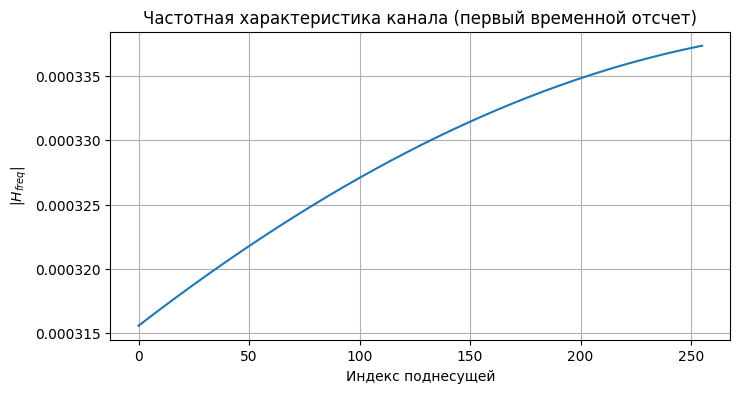

In [39]:
num_subcarriers = 256
subcarrier_spacing = 78.125e3

frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)
h_freq = result.cfr(frequencies=frequencies,
                    normalize=False,
                    normalize_delays=True,
                    out_type="numpy",
                    num_time_steps=num_time_steps)

print("Форма h_freq:", h_freq.shape)

plt.figure(figsize=(8, 4))
plt.plot(np.abs(h_freq[0, 0, 0, 0, 0, :]))
plt.xlabel("Индекс поднесущей")
plt.ylabel(r"$|H_{freq}|$")
plt.title("Частотная характеристика канала (первый временной отсчет)")
plt.grid(True)
plt.show()

Начинаем вычисление радиокарты. Это может занять некоторое время...
Расчёт радиокарты завершён.
Форма тензора RSS карты: (1, 80, 80)
Форма тензора координат центров ячеек: (80, 80, 3)


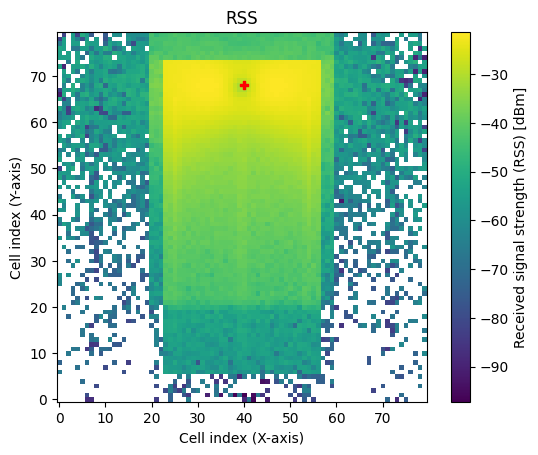

In [41]:
# 10. Построение радиокарты (Radio Map) для всей аудитории

# --- Настройки радиокарты ---
# Создаём плоскость для измерения на высоте 1 метр от пола.
# Центр карты совпадает с центром сцены (примерно [0, 0, 0]).
measurement_height = 0.4

# Размер карты: 8 метров по X и 8 метров по Y, чтобы покрыть всю аудиторию.
# Центр задаём так, чтобы карта покрывала область, представляющую интерес.
# Эти параметры могут потребовать подстройки под вашу конкретную сцену.
map_center = [0, 0, measurement_height]
map_size = [8, 8]  # [ширина по X, ширина по Y] в метрах

# Размер одной ячейки карты (чем меньше, тем выше разрешение, но больше расчёт).
cell_size = [0.1, 0.1]  # 10 см.

# Настройки трассировки для радиокарты
samples_per_tx = 10**6  # Количество семплов для Монте-Карло интеграции.
# Больше семплов = меньше шума на карте, но дольше расчёт. Начните с 10^6.

# Инициализируем солвер для радиокарт
rm_solver = RadioMapSolver()

print("Начинаем вычисление радиокарты. Это может занять некоторое время...")
# Вычисляем карту
rm = rm_solver(scene,
               max_depth=4,                # Такая же глубина лучей, как и ранее
               samples_per_tx=samples_per_tx,
               cell_size=cell_size,
               center=map_center,
               size=map_size,
               orientation=[0, 0, 0])      # Плоскость горизонтальна
print("Расчёт радиокарты завершён.")

# --- Визуализация ---
# Показываем карту уровня сигнала (RSS) на плоскости.
# Убедимся, что у передатчика задана мощность (по умолчанию 0 дБм, если не меняли).
rm.show(metric="rss")

# Для анализа можно также посмотреть карту усиления (path gain) в линейном масштабе:
# rm.show(metric="path_gain")

# --- Доступ к данным карты (опционально) ---
# Получить тензор RSS для всех ячеек.
# Форма: [1, num_cells_y, num_cells_x] для нашего случая с одним передатчиком.
rss_map_tensor = rm.rss
print(f"Форма тензора RSS карты: {rss_map_tensor.shape}")

# Получить координаты центров всех ячеек (в глобальной системе координат).
# Форма: [num_cells_y, num_cells_x, 3]
cell_centers = rm.cell_centers
print(f"Форма тензора координат центров ячеек: {cell_centers.shape}")